# Astronomy

AstroPy
- https://www.astropy.org/

StarPlot.dev
- https://starplot.dev/

ipyaladin (Aladin Lite)
- https://aladin.cds.unistra.fr/AladinLite/ipyaladin/
- https://github.com/cds-astro/ipyaladin


### Virtual Environment
activate venv before starting Jupyter Notebook

#### PyCharm

Settings > Python > Interpreter

+Icon (below interpreter): install packages astropy starplot ipyaladin

```bash
# Windows Command Prompt
.venv/Scripts/activate.bat
# Linux Terminal
source .venv/bin/activate
```

In [ ]:
# install packages in venv
!pip install astropy starplot ipyaladin

## AstroPy
- https://www.astropy.org/
- https://docs.astropy.org/en/stable/
- https://docs.astropy.org/en/stable/index_user_docs.html
- https://learn.astropy.org/
- https://github.com/astropy/astropy
- https://en.wikipedia.org/wiki/Astropy

In [23]:
import astropy.units as u

v = 30 * u.km/u.s

print(v)
print(v.value)
print(v.unit)

30.0 km / s
30.0
km / s


In [21]:
from astropy.constants import G, c, M_sun

print(G,c,M_sun,"\n")

  Name   = Gravitational constant
  Value  = 6.6743e-11
  Uncertainty  = 1.5e-15
  Unit  = m3 / (kg s2)
  Reference = CODATA 2022   Name   = Speed of light in vacuum
  Value  = 299792458.0
  Uncertainty  = 0.0
  Unit  = m / s
  Reference = CODATA 2022   Name   = Solar mass
  Value  = 1.988409870698051e+30
  Uncertainty  = 4.468805426856864e+25
  Unit  = kg
  Reference = IAU 2015 Resolution B 3 + CODATA 2022 



In [24]:
from astropy.coordinates import SkyCoord, EarthLocation, AltAz

m51 = SkyCoord.from_name('M51')

print("Sky coordinates of M51: ", m51)

# Load the position of the Observatory. Physical units should be assigned via the units function
gsn = EarthLocation(lat=50.59*u.deg, lon=8.67*u.deg, height=159*u.m)

print("Geocentric coordinates for Gießen: ", gsn)

Sky coordinates of M51:  <SkyCoord (ICRS): (ra, dec) in deg
    (202.469575, 47.19525833)>
Geocentric coordinates for Gießen:  (4011109.4179942133, 611636.7741040869, 4904837.474014905) m


### Astronomical Coordinate Systems

https://docs.astropy.org/en/stable/coordinates/index.html

In [38]:
from astropy import units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz

c = SkyCoord.from_name('M51')
print(c)

c = SkyCoord(ra=10.625*u.degree, dec=41.2*u.degree, frame='icrs')
print(c)

# equivalent ways to define the target
c = SkyCoord(10.625, 41.2, frame='icrs', unit='deg')
c = SkyCoord('00h42m30s', '+41d12m00s', frame='icrs')
c = SkyCoord('00h42.5m', '+41d12m')
print(c)
c = SkyCoord('00 42 30 +41 12 00', unit=(u.hourangle, u.deg))
c = SkyCoord('00:42.5 +41:12', unit=(u.hourangle, u.deg))
# import numpy as np
c = SkyCoord(ra=[10, 11, 12, 13]*u.degree, dec=[41, -5, 42, 0]*u.degree)
c = SkyCoord(ra=10.68458*u.degree, dec=41.26917*u.degree)

print("SkyCoord RA[hms] Dec[dms]: ", c.to_string('hmsdms'))

<SkyCoord (ICRS): (ra, dec) in deg
    (202.469575, 47.19525833)>
<SkyCoord (ICRS): (ra, dec) in deg
    (10.625, 41.2)>
<SkyCoord (ICRS): (ra, dec) in deg
    (10.625, 41.2)>
SkyCoord RA[hms] Dec[dms]:  00h42m44.2992s +41d16m09.012s


In [34]:
from astropy.coordinates import SkyCoord, EarthLocation, AltAz

# https://de.wikipedia.org/wiki/Orionnebel
# als Beispiel: 05h 35m 16,5s; −05° 23′ 23″

target = SkyCoord('05h35m16s', '-05d23m23s', frame='icrs')

ra=target.ra.degree
dec=target.dec.degree
print(ra)
print(dec)

83.81666666666665
-5.389722222222223


## StarPlot
- https://starplot.dev/
- https://starplot.dev/examples/
- https://starplot.dev/examples/star-chart-detail/
- https://starplot.dev/examples/map-big/
- https://starplot.dev/examples/map-orthographic/
- https://starplot.dev/examples/map-galaxy/
- https://starplot.dev/examples/map-custom-marker/
- https://starplotting.com/
- https://starplotting.com/blog/2025-10-12/plot.svg

Karten Projektion nur mit perspektivischen Verzerrungen (3D Sphere to 2D Rectangle)
- https://starplot.dev/tutorial/01/
- https://www.axismaps.com/guide/map-projections

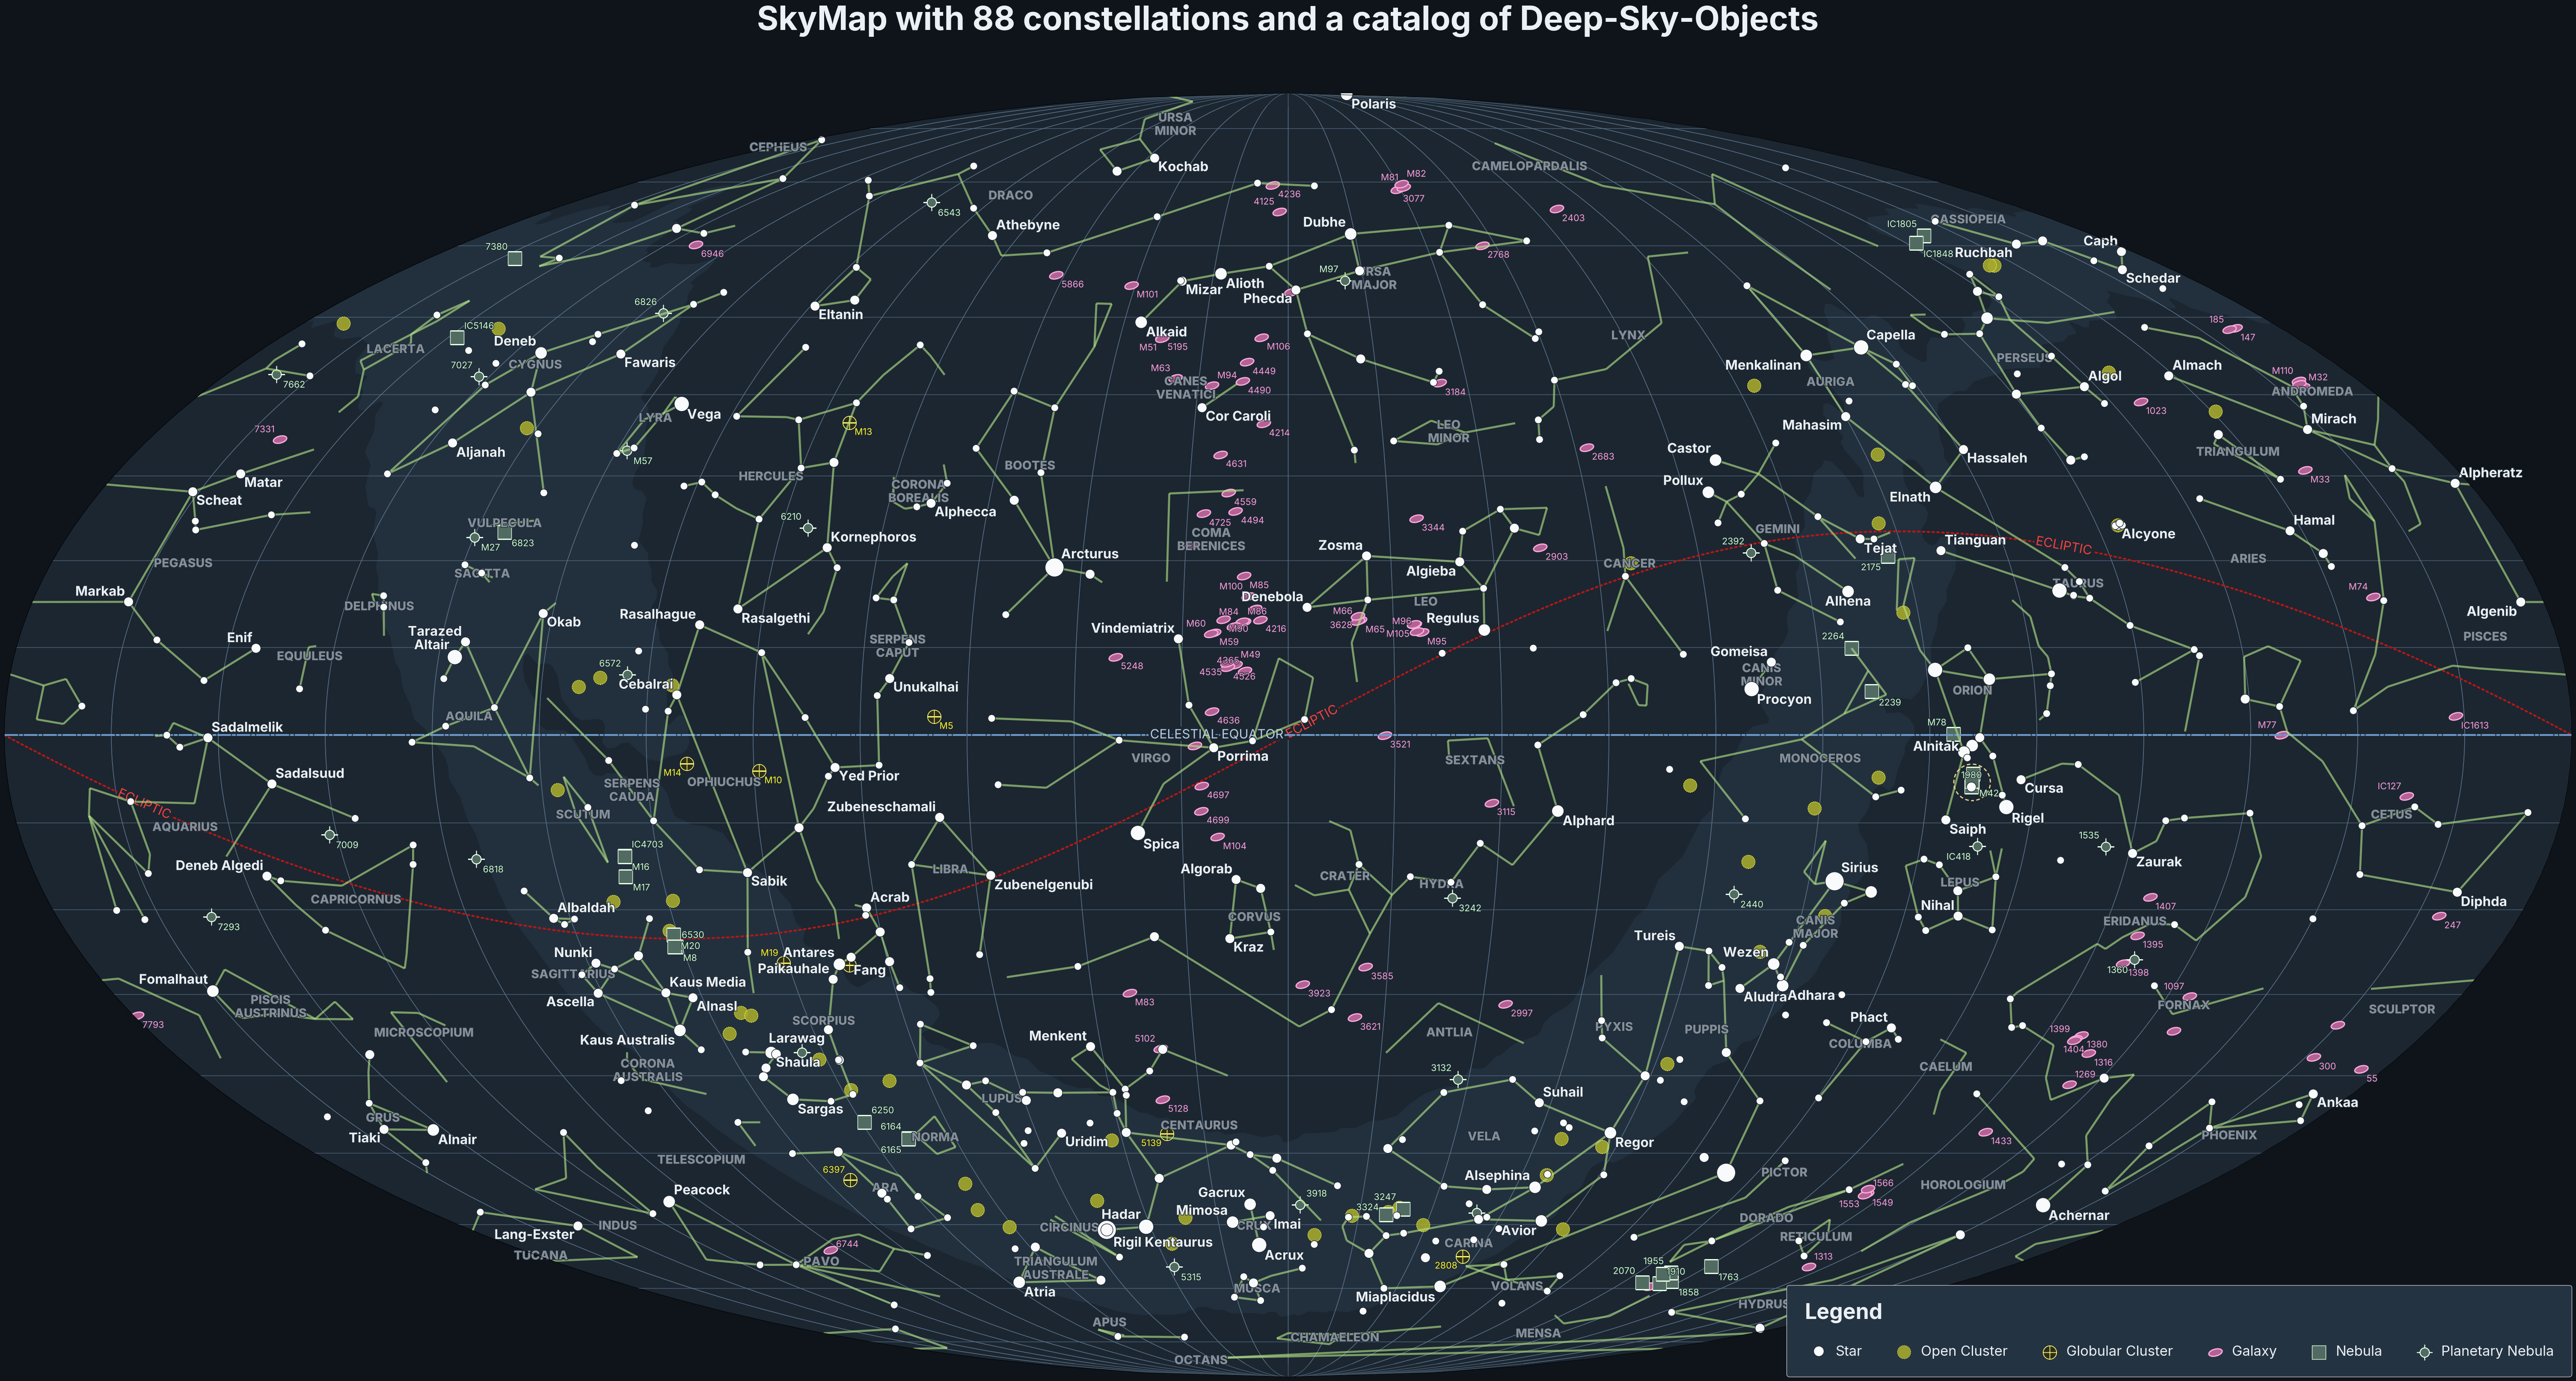

In [39]:
# https://starplotting.com/blog/celestial-sphere/
from starplot import (
    MapPlot,                      # ZenithPlot(), GalaxyPlot(),
    Mollweide,
    PlotStyle,
    style_extensions,             # extensions,
    _,
)

# definition for targets (others than Messier Objects)
mag = 10  # 12 for smart telescope, 6 for eye vision

# --------------------------------

style = PlotStyle().extend(
    style_extensions.BLUE_NIGHT,  # .BLUE_MEDIUM, extensions.BLUE_NIGHT,
    style_extensions.MAP,
)

'''
from datetime import datetime
from zoneinfo import ZoneInfo  # https://en.wikipedia.org/wiki/List_of_tz_database_time_zones

tz = ZoneInfo("Europe/Berlin")
dt = datetime(2026, 07, 19, 23, 00, tzinfo=tz)  # yyyy, mm, dd, hh, mm, tz

observer = Observer(
    dt=dt,
    lat=50.587222,  # https://de.wikipedia.org/wiki/Gie%C3%9Fen
    lon=8.669722,
)

# https://starplot.dev/examples/star-chart-detail/
p = ZenithPlot(
    observer=observer,
    style=style,
    resolution=3600,
    autoscale=True,
)
p.horizon()
'''

p = MapPlot(
    projection=Mollweide(),
    style=style,
    resolution=6000,
    autoscale=False,    # ?
    scale=0.8,
)

# --------------------------------

# decoration
p.gridlines(labels=False)
p.ecliptic(num_labels=3)
p.celestial_equator(num_labels=1)
p.milky_way()

# 88 Sternbilder
p.constellations()
#p.constellation_borders()
p.constellation_labels(style__font_size=20)

p.stars(
    where=[_.magnitude < 4],        # mag < 6: visible by eye; mag < 4 shows only constellations
    where_labels=[_.magnitude < 3],
)

# catalogs
'''
p.messier(
    where_true_size=[False],         # original: False
    label_fn=lambda d: f"M{d.m}",
)
'''
p.open_clusters(
    where=[_.magnitude < 6],
    where_labels=[False],
    where_true_size=[False],
)
p.globular_clusters(
    where=[_.magnitude < 6],
    where_labels=[True],            # original: False
    where_true_size=[False],
)
p.galaxies(
    where=[_.magnitude < mag],
    where_labels=[True],            # original: False
    where_true_size=[False],
)
p.nebula(
    where=[_.magnitude < mag],
    where_labels=[True],            # original: False
    where_true_size=[False],
)
#'''
# --------------------------------

# Markers (POI)
style_marker={
    "marker": {
        "size": 60,
        "symbol": "circle",
        "fill": "none",
        "color": None,
        "edge_color": "hsl(44, 70%, 73%)",
        "edge_width": 2,
        "line_style": [1, [2, 3]],
        "alpha": 1,
        "zorder": 100,
    },
    "label": {
        "zorder": 200,
        "font_size": 22,
        "font_weight": 700,
        "font_color": "hsl(44, 70%, 64%)",
        "font_alpha": 1,
        "offset_x": "auto",
        "offset_y": "auto",
        "anchor_point": "top right",
    },
}

from astropy import units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz

# TODO: make a for-loop for all targets in array
# https://de.wikipedia.org/wiki/Orionnebel : 05h 35m 16,5s; −05° 23′ 23″
target = SkyCoord('05h35m16s', '-05d23m23s', frame='icrs')

p.marker(
    ra=target.ra.degree,
    dec=target.dec.degree,
    style=style_marker,
    label="Orionnebel",
)

# --------------------------------

p.legend()
p.title("SkyMap with 88 constellations and a catalog of Deep-Sky-Objects", style__font_size=54)  # 86

p.export("starplot.svg", format="svg", padding=0.25, transparent=True)

Aladin Lite (ipyaladin)
- https://aladin.cds.unistra.fr/AladinLite/
- https://aladin.cds.unistra.fr/AladinLite/ipyaladin/
- https://github.com/cds-astro/ipyaladin
- https://github.com/cds-astro/ipyaladin/blob/master/examples/02_Base_Commands.ipynb
- https://cds-astro.github.io/ipyaladin/autoapi/ipyaladin/widget/index.html

In [20]:
from ipyaladin import Aladin
# use Sidecar to display the View beside the Notebook
from sidecar import Sidecar
from astropy.coordinates import Angle, SkyCoord

aladin = Aladin()
with Sidecar(title="Aladin Lite"):
    display(aladin)
aladin.target = "M51"
aladin.fov = Angle(1, "deg")
aladin

In [17]:
# https://github.com/cds-astro/ipyaladin/blob/master/examples/02_Base_Commands.ipynb
from astropy.coordinates import Angle, SkyCoord
from ipyaladin import Aladin, Marker
from pathlib import Path

aladin = Aladin(
    target=SkyCoord(10, 20, unit="deg"),
    fov=Angle(20, "deg"),
    reticle_size=64,
    reticle_color="#ff89ff",
)
aladin